# 5-Fold Cross-Validation — Attention Pooling Model
> Normal vs Crohn disease classification from scGPT cell embeddings.

### Key differences from discovery/validation split
- All donors go into a single pool — no pre-split at dataset level
- `StratifiedKFold` ensures each fold preserves the Crohn:Normal ratio
- Splits are at **donor level** — no donor ever appears in both train and val in any fold
- Best model per fold saved as `best_model_fold{k}.pt`
- Aggregate report at the end: mean ± std across all 5 folds

### Pipeline
```
data/all/<donor>_embeddings.npy  ──┐
data/all_labels.npy               ──┴──▶  StratifiedKFold (5 folds, donor-level)
                                              ↓  per fold
                                        Train AttentionPoolingModel
                                              ↓
                                        Evaluate on held-out fold donors
                                              ↓
                                        Aggregate metrics (mean ± std)
```

## Block 1 — Imports

In [2]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
)
import matplotlib.pyplot as plt

from attention_model import (
    AttentionPoolingModel,
    PatientDataset,
    collate_fn,
    load_all_patients_flat,
    set_seed,
)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")

PyTorch version : 2.8.0
CUDA available  : False
Using device    : cpu


## Block 2 — Reproducibility

In [3]:
set_seed(42)

Random seed set to 42 ✓


## Block 3 — Hyperparameters
Centralise all settings here — only cell you need to edit.

In [4]:
# ── Data ──────────────────────────────────────────────────────
D_H           = 512          # scGPT embedding dimension
NUM_CLASSES   = 2

# ── Training ──────────────────────────────────────────────────
BATCH_SIZE    = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 10
N_FOLDS       = 5
RANDOM_SEED   = 42

# ── Paths ──────────────────────────────────────────────────────
ALL_DATA_DIR    = "data/all/"          # all donor .npy files in one flat folder
ALL_LABELS_PATH = "data/all_labels.npy"

# ── Label names ────────────────────────────────────────────────
LABEL_NAMES = {0: "Normal", 1: "Crohn disease"}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")

Using device : cpu


## Block 4 — Helper Functions
`seed_worker`, `build_model`, `compute_class_weights`

In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_model():
    return AttentionPoolingModel(
        d_h=D_H, num_classes=NUM_CLASSES
    ).to(DEVICE)


def compute_class_weights(labels):
    """Inverse-frequency weighting — recomputed per fold from train split only."""
    n_total = len(labels)
    weights = []
    for c in range(NUM_CLASSES):
        n_c = (labels == c).sum()
        weights.append(n_total / (NUM_CLASSES * n_c))
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)

## Block 5 — Train and Evaluate Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for Z, mask, labels, _ in loader:

        Z = Z.to(DEVICE)
        mask = mask.to(DEVICE)
        labels = labels.to(DEVICE)

        Z = F.normalize(Z, dim=-1)

        optimizer.zero_grad()

        logits, _, _ = model(Z, mask)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / total
    acc = 100.0 * correct / total

    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for Z, mask, labels, _ in loader:

            Z = Z.to(DEVICE)
            mask = mask.to(DEVICE)
            labels = labels.to(DEVICE)

            Z = F.normalize(Z, dim=-1)

            logits, _, _ = model(Z, mask)

            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)

            preds = probs.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

            all_preds.append(preds.cpu())

            all_labels.append(labels.cpu())

            all_probs.append(probs.cpu())

    avg_loss = total_loss / total

    acc = 100.0 * correct / total

    preds_np = torch.cat(all_preds).numpy()

    labels_np = torch.cat(all_labels).numpy()

    probs_np = torch.cat(all_probs).numpy()

    return avg_loss, acc, preds_np, labels_np, probs_np

## Block 6 — Metrics Function

In [7]:
def compute_fold_metrics(labels_np, preds_np, probs_np):
    """Compute full suite of metrics for one fold."""
    disease_probs = probs_np[:, 1]

    cm             = confusion_matrix(labels_np, preds_np)
    TN, FP, FN, TP = cm.ravel()

    accuracy    = (TP + TN) / len(labels_np)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1          = (2 * precision * sensitivity / (precision + sensitivity)
                   if (precision + sensitivity) > 0 else 0.0)

    # Guard AUROC — needs both classes present in fold
    try:
        auroc = roc_auc_score(labels_np, disease_probs)
    except ValueError:
        auroc = float("nan")

    try:
        auprc = average_precision_score(labels_np, disease_probs)
    except ValueError:
        auprc = float("nan")

    mcc   = matthews_corrcoef(labels_np, preds_np)
    brier = brier_score_loss(labels_np, disease_probs)

    return dict(
        accuracy=accuracy, sensitivity=sensitivity, specificity=specificity,
        precision=precision, f1=f1, auroc=auroc, auprc=auprc,
        mcc=mcc, brier=brier,
        TP=TP, TN=TN, FP=FP, FN=FN,
    )

## Block 7 — Load All Patients
All donors load into a single flat list. `StratifiedKFold` will split them in the next block.

In [8]:
set_seed(RANDOM_SEED)

patient_list, donor_ids, all_labels = load_all_patients_flat(
    ALL_DATA_DIR, ALL_LABELS_PATH
)

print(f"Total donors  : {len(patient_list)}")
print(f"  Normal (0)  : {(all_labels == 0).sum()}")
print(f"  Crohn  (1)  : {(all_labels == 1).sum()}")

Random seed set to 42 ✓


Total donors  : 50
  Normal (0)  : 14
  Crohn  (1)  : 36


## Block 8 — Preview 5-Fold Splits (Dry Run)
Inspect which donors fall into each fold before training starts.
> 💡 Run this to verify class balance and confirm zero donor overlap across splits.

In [9]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

print(f"5-Fold CV split preview")
print("=" * 65)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(np.arange(len(patient_list)), all_labels), start=1
):
    train_labels_fold = all_labels[train_idx]
    val_labels_fold   = all_labels[val_idx]

    overlap = set(train_idx) & set(val_idx)
    assert len(overlap) == 0, f"Leakage in fold {fold}!"

    print(f"Fold {fold}:")
    print(f"  Train : {len(train_idx):>3} donors  "
          f"Normal={(train_labels_fold==0).sum():>2}  "
          f"Crohn={(train_labels_fold==1).sum():>2}")
    print(f"  Val   : {len(val_idx):>3} donors  "
          f"Normal={(val_labels_fold==0).sum():>2}  "
          f"Crohn={(val_labels_fold==1).sum():>2}")
    print(f"  Overlap : 0 ✓")
    print()

print("All splits verified — no donor leakage ✓")

5-Fold CV split preview
Fold 1:
  Train :  40 donors  Normal=11  Crohn=29
  Val   :  10 donors  Normal= 3  Crohn= 7
  Overlap : 0 ✓

Fold 2:
  Train :  40 donors  Normal=11  Crohn=29
  Val   :  10 donors  Normal= 3  Crohn= 7
  Overlap : 0 ✓

Fold 3:
  Train :  40 donors  Normal=11  Crohn=29
  Val   :  10 donors  Normal= 3  Crohn= 7
  Overlap : 0 ✓

Fold 4:
  Train :  40 donors  Normal=11  Crohn=29
  Val   :  10 donors  Normal= 3  Crohn= 7
  Overlap : 0 ✓

Fold 5:
  Train :  40 donors  Normal=12  Crohn=28
  Val   :  10 donors  Normal= 2  Crohn= 8
  Overlap : 0 ✓

All splits verified — no donor leakage ✓


## Block 9 — 5-Fold CV Training Loop

For each fold:
1. Split donors into train / val
2. Recompute class weights from **train split only**
3. Initialise a fresh model + Adam + CosineAnnealingLR
4. Train for `NUM_EPOCHS`, save best checkpoint by val accuracy
5. Store per-donor predictions and metrics at best epoch

In [10]:
fold_metrics     = []
all_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(np.arange(len(patient_list)), all_labels), start=1
):
    print(f"\n{'─'*65}")
    print(f"  FOLD {fold}/{N_FOLDS}   "
          f"train={len(train_idx)} donors  val={len(val_idx)} donors")
    print(f"{'─'*65}")

    assert len(set(train_idx) & set(val_idx)) == 0

    train_data        = [patient_list[i] for i in train_idx]
    val_data          = [patient_list[i] for i in val_idx]
    train_labels_fold = all_labels[train_idx]

    print(f"  Train class balance: "
          f"Normal={(train_labels_fold==0).sum()}  "
          f"Crohn={(train_labels_fold==1).sum()}")

    # ── DataLoaders ──────────────────────────────────────────────
    g = torch.Generator()
    g.manual_seed(RANDOM_SEED + fold)

    train_loader = DataLoader(
        PatientDataset(train_data),
        batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate_fn, worker_init_fn=seed_worker, generator=g,
    )
    val_loader = DataLoader(
        PatientDataset(val_data),
        batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_fn, worker_init_fn=seed_worker, generator=g,
    )

    # ── Model, optimiser, loss ───────────────────────────────────
    set_seed(RANDOM_SEED + fold)
    model     = build_model()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS
    )
    criterion = nn.CrossEntropyLoss(
        weight=compute_class_weights(train_labels_fold)
    )

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params : {total_params:,}")

    best_val_acc = 0.0
    best_epoch   = 1
    best_preds   = None
    best_labels  = None
    best_probs   = None

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_acc                              = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, preds_np, labels_np, probs_np = evaluate(model, val_loader, criterion)
        scheduler.step()

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_epoch   = epoch + 1
            best_preds   = preds_np
            best_labels  = labels_np
            best_probs   = probs_np
            torch.save(model.state_dict(), f"best_model_fold{fold}.pt")
            print(f"    ✓ Saved fold {fold} best model  "
                  f"(epoch {epoch+1}, val_acc={vl_acc:.1f}%)")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Ep [{epoch+1:02d}/{NUM_EPOCHS}]  "
                  f"TrainLoss={tr_loss:.4f}  TrainAcc={tr_acc:.1f}%  "
                  f"ValLoss={vl_loss:.4f}  ValAcc={vl_acc:.1f}%")

    # ── Metrics at best epoch ────────────────────────────────────
    metrics               = compute_fold_metrics(best_labels, best_preds, best_probs)
    metrics["fold"]       = fold
    metrics["best_epoch"] = best_epoch
    metrics["best_val_acc"] = best_val_acc
    fold_metrics.append(metrics)

    # ── Per-donor result table ───────────────────────────────────
    def outcome(t, p):
        if t == 0 and p == 0: return "TN — Correct Normal"
        if t == 1 and p == 1: return "TP — Correct Crohn"
        if t == 0 and p == 1: return "FP — Normal→Crohn"
        return                       "FN — Crohn→Normal"

    fold_rows = [
        {
            "fold"       : fold,
            "donor_id"   : donor_ids[val_idx[i]],
            "true"       : LABEL_NAMES[int(best_labels[i])],
            "pred"       : LABEL_NAMES[int(best_preds[i])],
            "prob_normal": round(float(best_probs[i, 0]), 3),
            "prob_crohn" : round(float(best_probs[i, 1]), 3),
            "correct"    : bool(best_preds[i] == best_labels[i]),
            "outcome"    : outcome(int(best_labels[i]), int(best_preds[i])),
        }
        for i in range(len(best_preds))
    ]
    all_fold_results.extend(fold_rows)

    print(f"\n  Fold {fold} summary → "
          f"AUROC={metrics['auroc']:.3f}  "
          f"MCC={metrics['mcc']:.3f}  "
          f"F1={metrics['f1']:.3f}  "
          f"Acc={metrics['accuracy']*100:.1f}%  "
          f"Sen={metrics['sensitivity']*100:.1f}%  "
          f"Spe={metrics['specificity']*100:.1f}%")


─────────────────────────────────────────────────────────────────
  FOLD 1/5   train=40 donors  val=10 donors
─────────────────────────────────────────────────────────────────
  Train class balance: Normal=11  Crohn=29
Random seed set to 43 ✓


  Trainable params : 263,427


    ✓ Saved fold 1 best model  (epoch 1, val_acc=60.0%)
  Ep [01/10]  TrainLoss=0.6937  TrainAcc=35.0%  ValLoss=0.6893  ValAcc=60.0%


    ✓ Saved fold 1 best model  (epoch 2, val_acc=90.0%)


  Ep [05/10]  TrainLoss=0.6565  TrainAcc=87.5%  ValLoss=0.6609  ValAcc=80.0%


...

    ✓ Saved fold 5 best model  (epoch 2, val_acc=40.0%)


    ✓ Saved fold 5 best model  (epoch 3, val_acc=70.0%)


    ✓ Saved fold 5 best model  (epoch 4, val_acc=90.0%)


  Ep [05/10]  TrainLoss=0.6530  TrainAcc=87.5%  ValLoss=0.6529  ValAcc=90.0%


  Ep [10/10]  TrainLoss=0.6241  TrainAcc=90.0%  ValLoss=0.6267  ValAcc=90.0%

  Fold 5 summary → AUROC=0.938  MCC=0.764  F1=0.933  Acc=90.0%  Sen=87.5%  Spe=100.0%


## Block 10 — Aggregate Metrics (mean ± std across folds)

In [11]:
metric_keys  = ["accuracy", "sensitivity", "specificity",
                "precision", "f1", "auroc", "auprc", "mcc", "brier"]
summary_rows = []

print("=" * 65)
print("  5-FOLD CV — AGGREGATE METRICS")
print("=" * 65)

for key in metric_keys:
    values = [m[key] for m in fold_metrics if not np.isnan(m[key])]
    mean_v = np.mean(values)
    std_v  = np.std(values)
    label  = key.upper().replace("_", " ")
    print(f"  {label:<20} : {mean_v:.3f} ± {std_v:.3f}   "
          f"[{min(values):.3f} – {max(values):.3f}]")
    summary_rows.append({"metric": key, "mean": mean_v, "std": std_v,
                          "min": min(values), "max": max(values)})

print("=" * 65)
print("\nPer-fold breakdown:")
for m in fold_metrics:
    print(f"  Fold {m['fold']}  "
          f"Acc={m['accuracy']*100:.1f}%  "
          f"AUROC={m['auroc']:.3f}  "
          f"MCC={m['mcc']:.3f}  "
          f"TP={m['TP']} TN={m['TN']} FP={m['FP']} FN={m['FN']}  "
          f"best_epoch={m['best_epoch']}")

  5-FOLD CV — AGGREGATE METRICS
  ACCURACY             : 0.880 ± 0.040   [0.800 – 0.900]
  SENSITIVITY          : 0.975 ± 0.050   [0.875 – 1.000]
  SPECIFICITY          : 0.667 ± 0.211   [0.333 – 1.000]
  PRECISION            : 0.881 ± 0.071   [0.778 – 1.000]
  F1                   : 0.922 ± 0.023   [0.875 – 0.933]
  AUROC                : 0.873 ± 0.113   [0.667 – 1.000]
  AUPRC                : 0.946 ± 0.055   [0.844 – 1.000]
  MCC                  : 0.713 ± 0.102   [0.509 – 0.764]
  BRIER                : 0.239 ± 0.003   [0.234 – 0.242]

Per-fold breakdown:
  Fold 1  Acc=90.0%  AUROC=0.857  MCC=0.764  TP=7 TN=2 FP=1 FN=0  best_epoch=2
  Fold 2  Acc=90.0%  AUROC=1.000  MCC=0.764  TP=7 TN=2 FP=1 FN=0  best_epoch=2
  Fold 3  Acc=90.0%  AUROC=0.905  MCC=0.764  TP=7 TN=2 FP=1 FN=0  best_epoch=3
  Fold 4  Acc=80.0%  AUROC=0.667  MCC=0.509  TP=7 TN=1 FP=2 FN=0  best_epoch=5
  Fold 5  Acc=90.0%  AUROC=0.938  MCC=0.764  TP=7 TN=2 FP=0 FN=1  best_epoch=4


## Block 11 — Save Results to CSV

In [12]:
results_df = pd.DataFrame(all_fold_results)
results_df.to_csv("cv_donor_results.csv", index=False)
print("Saved → cv_donor_results.csv ✓")
print(results_df.head(10).to_string(index=False))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("cv_metric_summary.csv", index=False)
print("\nSaved → cv_metric_summary.csv ✓")
print(summary_df.to_string(index=False))

Saved → cv_donor_results.csv ✓
 fold donor_id          true          pred  prob_normal  prob_crohn  correct             outcome
    1   125985 Crohn disease Crohn disease        0.490       0.510     True  TP — Correct Crohn
    1   128346 Crohn disease Crohn disease        0.488       0.512     True  TP — Correct Crohn
    1   128400 Crohn disease Crohn disease        0.495       0.505     True  TP — Correct Crohn
    1   165697 Crohn disease Crohn disease        0.485       0.515     True  TP — Correct Crohn
    1   171336 Crohn disease Crohn disease        0.490       0.510     True  TP — Correct Crohn
    1   176196 Crohn disease Crohn disease        0.493       0.507     True  TP — Correct Crohn
    1   180844        Normal Crohn disease        0.493       0.507    False   FP — Normal→Crohn
    1   191305 Crohn disease Crohn disease        0.495       0.505     True  TP — Correct Crohn
    1      N13        Normal        Normal        0.502       0.498     True TN — Correct Normal

## Block 12 — Plot Per-Fold Metrics

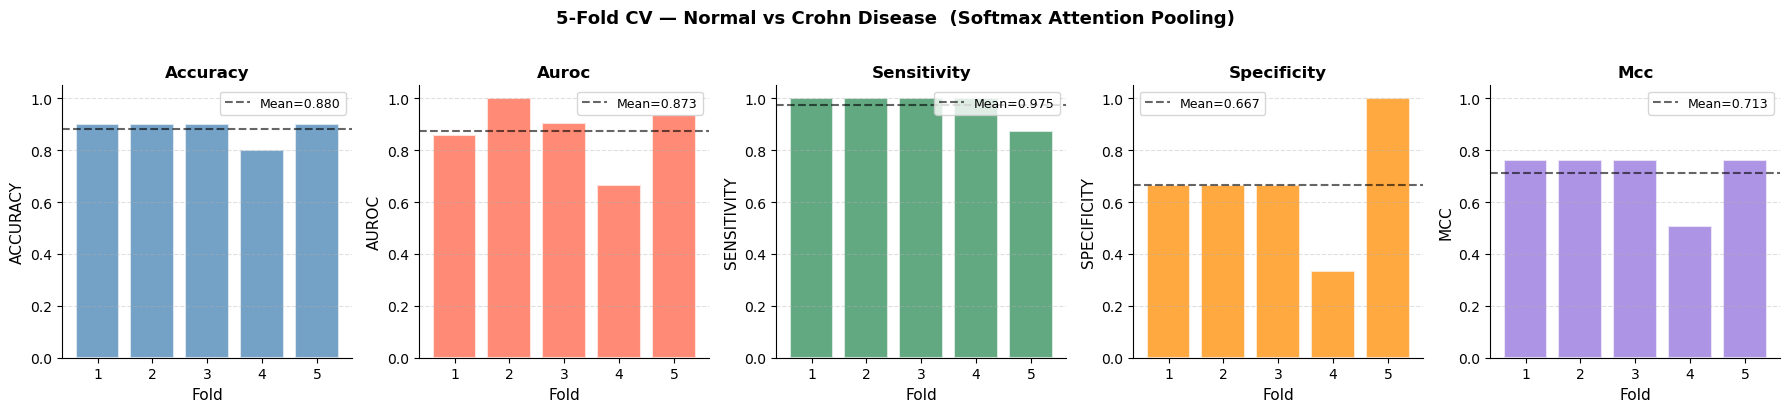

Saved → cv_fold_metrics.png ✓


In [13]:
folds           = [m["fold"] for m in fold_metrics]
metrics_to_plot = ["accuracy", "auroc", "sensitivity", "specificity", "mcc"]
colors          = ["steelblue", "tomato", "seagreen", "darkorange", "mediumpurple"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))

for ax, key, color in zip(axes, metrics_to_plot, colors):
    values = [m[key] for m in fold_metrics]
    mean_v = np.mean(values)

    ax.bar(folds, values, color=color, alpha=0.75,
           edgecolor="white", linewidth=1.5)
    ax.axhline(mean_v, color="black", linestyle="--", alpha=0.6,
               label=f"Mean={mean_v:.3f}")
    ax.set_xlabel("Fold", fontsize=11)
    ax.set_ylabel(key.upper(), fontsize=11)
    ax.set_title(key.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xticks(folds)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "5-Fold CV — Normal vs Crohn Disease  (Softmax Attention Pooling)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("cv_fold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → cv_fold_metrics.png ✓")

## Block 13 — Training Curves per Fold
> Re-run each fold individually and capture `train_losses` / `val_losses` if you want per-fold curves.
> This block plots the **val accuracy per fold** as a summary curve.

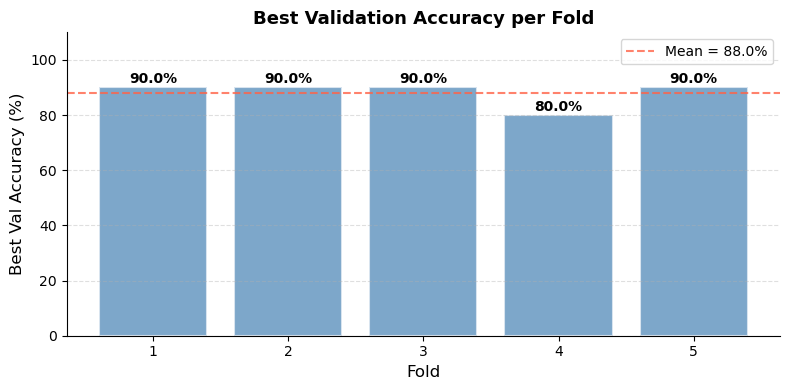

Saved → cv_best_acc_per_fold.png ✓


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

for m in fold_metrics:
    ax.bar(m["fold"], m["best_val_acc"],
           color="steelblue", alpha=0.7, edgecolor="white", linewidth=1.5)
    ax.text(m["fold"], m["best_val_acc"] + 0.5,
            f"{m['best_val_acc']:.1f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

mean_acc = np.mean([m["best_val_acc"] for m in fold_metrics])
ax.axhline(mean_acc, color="tomato", linestyle="--", alpha=0.8,
           label=f"Mean = {mean_acc:.1f}%")

ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Best Val Accuracy (%)", fontsize=12)
ax.set_title("Best Validation Accuracy per Fold", fontsize=13, fontweight="bold")
ax.set_xticks([m["fold"] for m in fold_metrics])
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("cv_best_acc_per_fold.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → cv_best_acc_per_fold.png ✓")

## Block 14 — Per-Donor Prediction Table (all folds)

In [15]:
print("=" * 85)
print("  PER-DONOR PREDICTIONS ACROSS ALL FOLDS")
print("=" * 85)
print(results_df.sort_values(["fold", "outcome"]).to_string(index=False))

print("\n" + "=" * 85)
print("  OUTCOME SUMMARY (aggregated)")
print("=" * 85)
print(results_df["outcome"].value_counts().to_string())

overall_acc = results_df["correct"].mean() * 100
print(f"\nOverall accuracy across all held-out donors : {overall_acc:.1f}%")

  PER-DONOR PREDICTIONS ACROSS ALL FOLDS
 fold donor_id          true          pred  prob_normal  prob_crohn  correct             outcome
    1   180844        Normal Crohn disease        0.493       0.507    False   FP — Normal→Crohn
    1      N13        Normal        Normal        0.502       0.498     True TN — Correct Normal
    1      N15        Normal        Normal        0.517       0.483     True TN — Correct Normal
    1   125985 Crohn disease Crohn disease        0.490       0.510     True  TP — Correct Crohn
    1   128346 Crohn disease Crohn disease        0.488       0.512     True  TP — Correct Crohn
    1   128400 Crohn disease Crohn disease        0.495       0.505     True  TP — Correct Crohn
    1   165697 Crohn disease Crohn disease        0.485       0.515     True  TP — Correct Crohn
    1   171336 Crohn disease Crohn disease        0.490       0.510     True  TP — Correct Crohn
    1   176196 Crohn disease Crohn disease        0.493       0.507     True  TP — Cor

2026-05-11 13:36:58.534979: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Total donors : 50

Generating UMAP for Fold 1


Embedding matrix : (50, 512)


UMAP fitted ✓


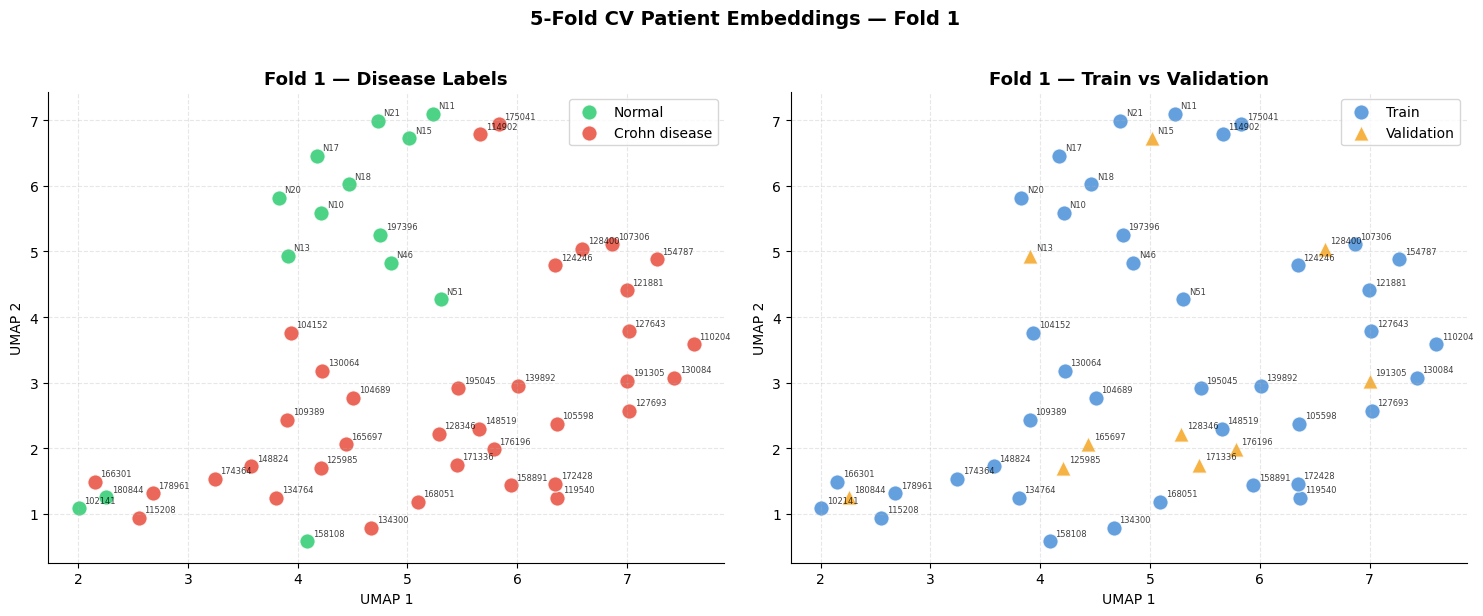

Saved → patient_umap_fold1.png ✓

Generating UMAP for Fold 2


Embedding matrix : (50, 512)
UMAP fitted ✓


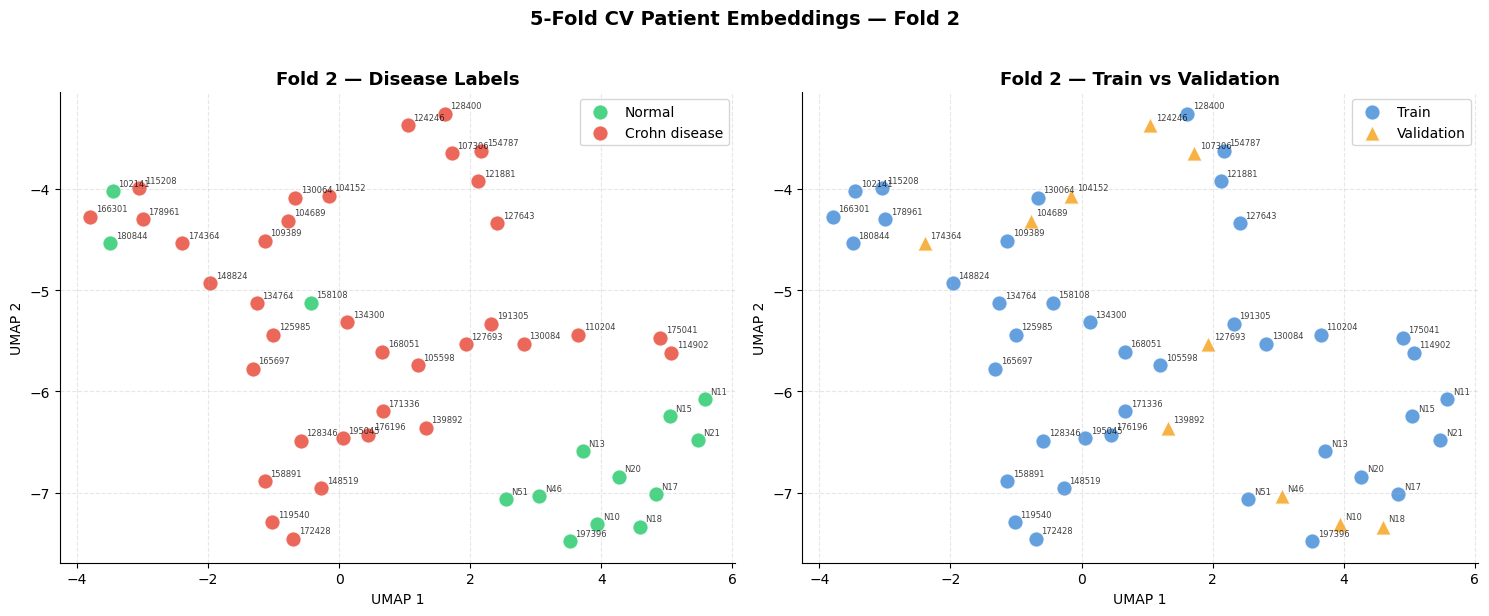

Saved → patient_umap_fold2.png ✓

Generating UMAP for Fold 3


Embedding matrix : (50, 512)
UMAP fitted ✓


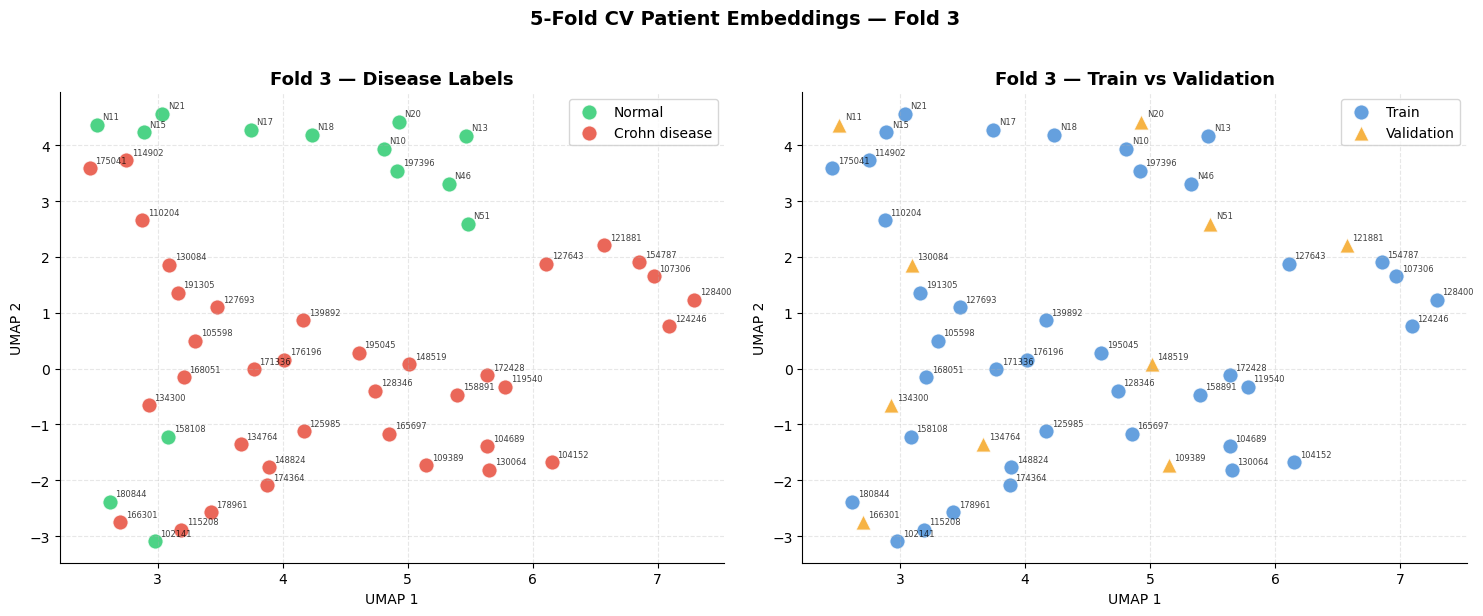

Saved → patient_umap_fold3.png ✓

Generating UMAP for Fold 4


Embedding matrix : (50, 512)
UMAP fitted ✓


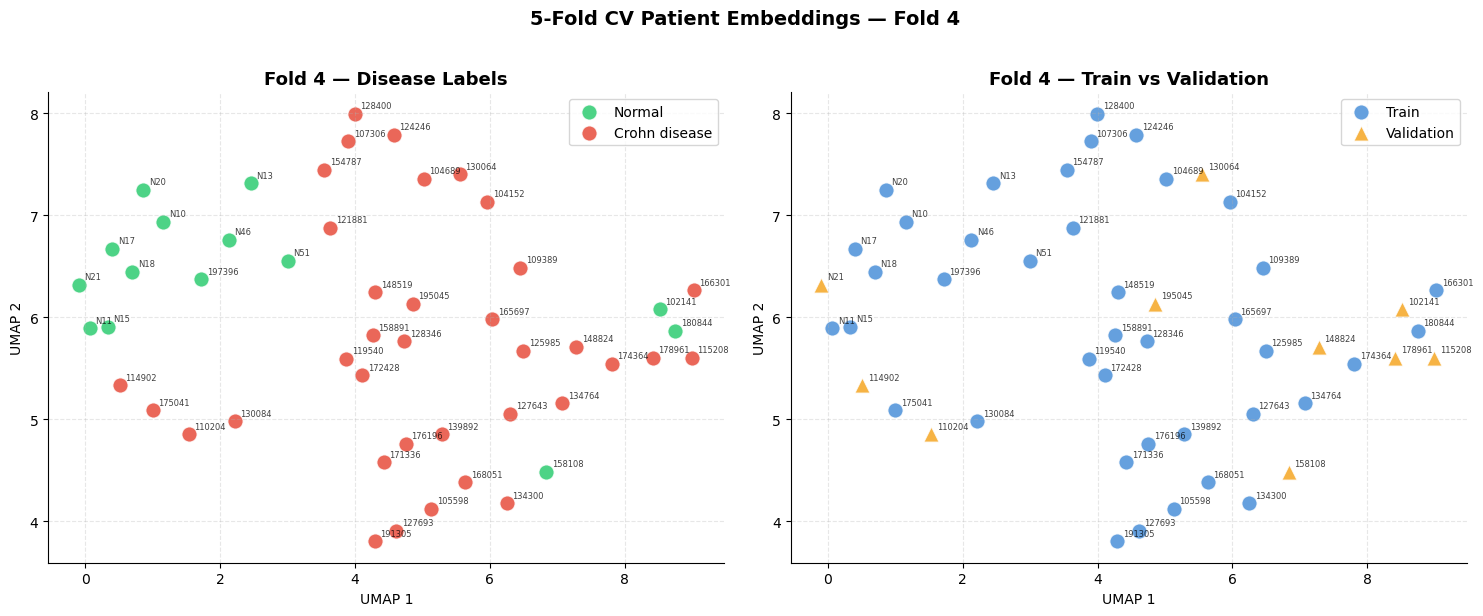

Saved → patient_umap_fold4.png ✓

Generating UMAP for Fold 5


Embedding matrix : (50, 512)
UMAP fitted ✓


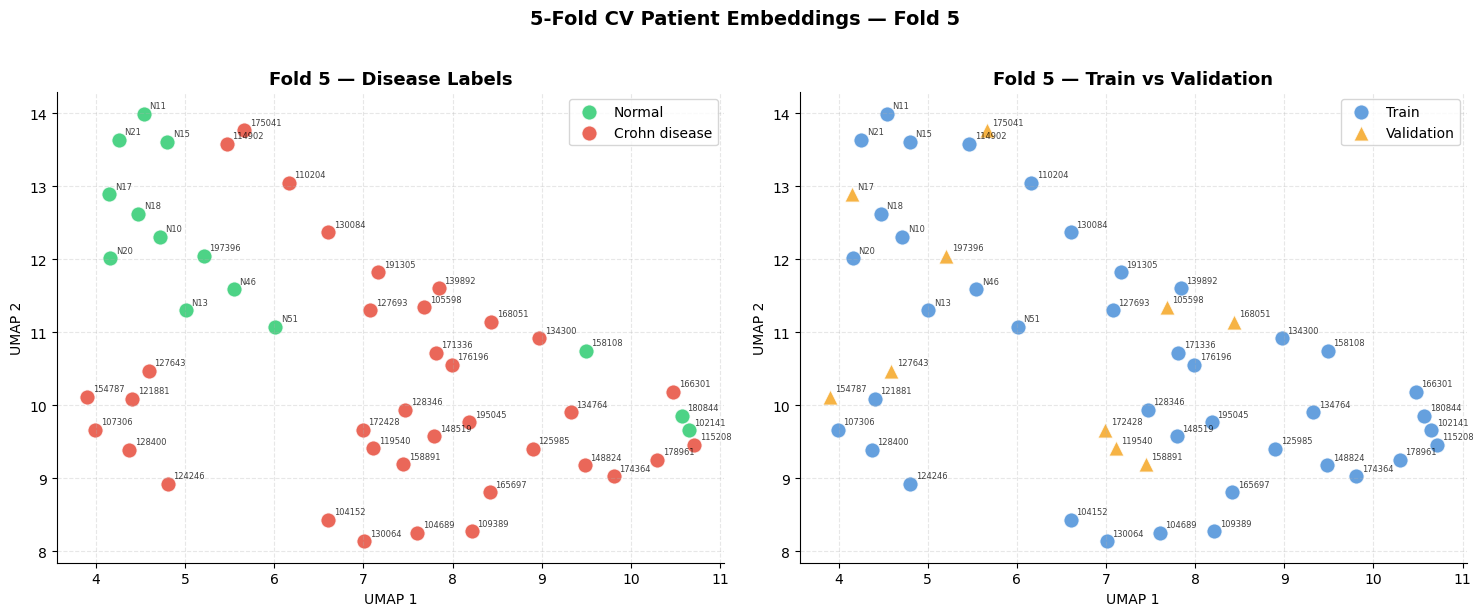

Saved → patient_umap_fold5.png ✓


In [16]:
# =========================================================
# UMAP VISUALIZATION FOR 5-FOLD CV MODELS
# =========================================================

import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from umap import UMAP

from attention_model import (
    AttentionPoolingModel,
    PatientDataset,
    collate_fn,
    load_all_patients_flat,
)

# =========================================================
# LOAD ALL DONORS
# =========================================================

patient_list, donor_ids, all_labels = (
    load_all_patients_flat(
        ALL_DATA_DIR,
        ALL_LABELS_PATH
    )
)

print(f"Total donors : {len(patient_list)}")

# =========================================================
# 5-FOLD SPLITS
# =========================================================

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED
)

# =========================================================
# PLOT SETTINGS
# =========================================================

color_map = {
    0: "#2ecc71",
    1: "#e74c3c"
}

label_map_r = {
    0: "Normal",
    1: "Crohn disease"
}

split_color_map = {
    "Train": "#4A90D9",
    "Validation": "#F5A623"
}

# =========================================================
# LOOP THROUGH FOLDS
# =========================================================

for fold, (train_idx, val_idx) in enumerate(
    skf.split(np.arange(len(patient_list)), all_labels),
    start=1
):

    print("\n" + "=" * 70)
    print(f"Generating UMAP for Fold {fold}")
    print("=" * 70)

    # -----------------------------------------------------
    # Fold-specific donor splits
    # -----------------------------------------------------

    train_patients = [
        patient_list[i]
        for i in train_idx
    ]

    val_patients = [
        patient_list[i]
        for i in val_idx
    ]

    train_donor_ids = [
        donor_ids[i]
        for i in train_idx
    ]

    val_donor_ids = [
        donor_ids[i]
        for i in val_idx
    ]

    # -----------------------------------------------------
    # Datasets
    # -----------------------------------------------------

    train_dataset = PatientDataset(train_patients)

    val_dataset = PatientDataset(val_patients)

    # -----------------------------------------------------
    # Dataloaders
    # -----------------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )

    # -----------------------------------------------------
    # Build model
    # -----------------------------------------------------

    model = AttentionPoolingModel(
        d_h=D_H,
        num_classes=NUM_CLASSES
    ).to(DEVICE)

    # -----------------------------------------------------
    # Load trained fold model
    # -----------------------------------------------------

    model.load_state_dict(
        torch.load(
            f"best_model_fold{fold}.pt",
            map_location=DEVICE
        )
    )

    model.eval()

    # -----------------------------------------------------
    # Collect embeddings
    # -----------------------------------------------------

    all_embs = []
    all_labels_np = []

    donor_labels = []
    split_flags = []

    # -----------------------------------------------------
    # TRAIN DONORS
    # -----------------------------------------------------

    train_counter = 0

    with torch.no_grad():

        for Z, mask, labels, patient_ids in train_loader:

            Z = Z.to(DEVICE)
            mask = mask.to(DEVICE)

            Z = F.normalize(Z, dim=-1)

            _, patient_emb, _ = model(Z, mask)

            patient_emb = patient_emb.cpu()

            all_embs.append(patient_emb)

            all_labels_np.append(labels)

            donor_labels.extend(patient_ids)
            
            split_flags.extend(
                ["Train"] * len(patient_ids)
            )

    # -----------------------------------------------------
    # VALIDATION DONORS
    # -----------------------------------------------------

    val_counter = 0

    with torch.no_grad():

        for Z, mask, labels, patient_ids in val_loader:

            Z = Z.to(DEVICE)
            mask = mask.to(DEVICE)

            Z = F.normalize(Z, dim=-1)

            _, patient_emb, _ = model(Z, mask)

            patient_emb = patient_emb.cpu()

            all_embs.append(patient_emb)

            all_labels_np.append(labels)

            donor_labels.extend(patient_ids)

            split_flags.extend(
                ["Validation"] * len(patient_ids)
            )

    # -----------------------------------------------------
    # Concatenate
    # -----------------------------------------------------

    all_embs_np = torch.cat(all_embs).numpy()

    all_labels_np = torch.cat(
        all_labels_np
    ).numpy()

    print(f"Embedding matrix : {all_embs_np.shape}")

    # -----------------------------------------------------
    # UMAP
    # -----------------------------------------------------

    reducer = UMAP(
        n_components=2,
        n_neighbors=5,
        min_dist=0.3,
        random_state=42
    )

    embedding_2d = reducer.fit_transform(
        all_embs_np
    )

    print("UMAP fitted ✓")

    # =====================================================
    # PLOT
    # =====================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    # -----------------------------------------------------
    # LEFT : Disease labels
    # -----------------------------------------------------

    for label_val in [0, 1]:

        idx = all_labels_np == label_val

        axes[0].scatter(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            c=color_map[label_val],
            label=label_map_r[label_val],
            s=120,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.8
        )

    # donor annotations
    for i, did in enumerate(donor_labels):

        axes[0].annotate(
            did,
            (
                embedding_2d[i, 0],
                embedding_2d[i, 1]
            ),
            fontsize=6,
            alpha=0.75,
            xytext=(4, 4),
            textcoords="offset points"
        )

    axes[0].set_title(
        f"Fold {fold} — Disease Labels",
        fontsize=13,
        fontweight="bold"
    )

    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")

    axes[0].legend()

    # -----------------------------------------------------
    # RIGHT : Train vs Validation
    # -----------------------------------------------------

    for split in ["Train", "Validation"]:

        idx = np.array(split_flags) == split

        axes[1].scatter(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            c=split_color_map[split],
            label=split,
            s=120,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.8,
            marker="o" if split == "Train" else "^"
        )

    # donor annotations
    for i, did in enumerate(donor_labels):

        axes[1].annotate(
            did,
            (
                embedding_2d[i, 0],
                embedding_2d[i, 1]
            ),
            fontsize=6,
            alpha=0.75,
            xytext=(4, 4),
            textcoords="offset points"
        )

    axes[1].set_title(
        f"Fold {fold} — Train vs Validation",
        fontsize=13,
        fontweight="bold"
    )

    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")

    axes[1].legend()

    # -----------------------------------------------------
    # Styling
    # -----------------------------------------------------

    for ax in axes:

        ax.grid(
            True,
            linestyle="--",
            alpha=0.3
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # -----------------------------------------------------
    # Main title
    # -----------------------------------------------------

    plt.suptitle(
        f"5-Fold CV Patient Embeddings — Fold {fold}",
        fontsize=14,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------

    save_path = f"patient_umap_fold{fold}.png"

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved → {save_path} ✓")

In [16]:
pip install umap-learn

  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)


Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]


Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import os

# ---------------------------------------------------------
# Load CSV
# ---------------------------------------------------------

df = pd.read_csv("cv_donor_results.csv")

print(df.head())

# ---------------------------------------------------------
# Create output directory
# ---------------------------------------------------------

output_dir = "cv_fold_csvs"

os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# Split by fold
# ---------------------------------------------------------

for fold in sorted(df["fold"].unique()):

    fold_df = df[df["fold"] == fold]

    save_path = os.path.join(
        output_dir,
        f"fold_{fold}_results.csv"
    )

    fold_df.to_csv(save_path, index=False)

    print(
        f"Saved Fold {fold} "
        f"-> {save_path} "
        f"({len(fold_df)} donors)"
    )

   fold donor_id           true           pred  prob_normal  prob_crohn  \
0     1   125985  Crohn disease  Crohn disease        0.490       0.510   
1     1   128346  Crohn disease  Crohn disease        0.488       0.512   
2     1   128400  Crohn disease  Crohn disease        0.495       0.505   
3     1   165697  Crohn disease  Crohn disease        0.485       0.515   
4     1   171336  Crohn disease  Crohn disease        0.490       0.510   

   correct             outcome  
0     True  TP — Correct Crohn  
1     True  TP — Correct Crohn  
2     True  TP — Correct Crohn  
3     True  TP — Correct Crohn  
4     True  TP — Correct Crohn  
Saved Fold 1 -> cv_fold_csvs/fold_1_results.csv (10 donors)
Saved Fold 2 -> cv_fold_csvs/fold_2_results.csv (10 donors)
Saved Fold 3 -> cv_fold_csvs/fold_3_results.csv (10 donors)
Saved Fold 4 -> cv_fold_csvs/fold_4_results.csv (10 donors)
Saved Fold 5 -> cv_fold_csvs/fold_5_results.csv (10 donors)


In [18]:
import pandas as pd

# ---------------------------------------------------------
# Load full CV results
# ---------------------------------------------------------

df = pd.read_csv("cv_donor_results.csv")

# ---------------------------------------------------------
# Filter incorrect predictions
# ---------------------------------------------------------

false_df = df[df["correct"] == False]

print(f"Total incorrect donors : {len(false_df)}")

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

false_df.to_csv(
    "cv_false_predictions.csv",
    index=False
)

print("Saved -> cv_false_predictions.csv")

Total incorrect donors : 6
Saved -> cv_false_predictions.csv
